# Bird Outbreak Activity vs Poultry Commodity Movement

## 1. Problem Statement

This notebook tests whether bird outbreak activity from WAHIS helps explain or predict poultry-related commodity movement from FAOSTAT.

The two main data issues are:

- WAHIS is event-level, duplicated, and messy
- FAOSTAT is yearly and already aggregated

So the real task is:

`event deduplication -> time aggregation -> feature design -> target design -> forecasting`

This revision focuses on three practical fixes:

1. use a more stable target than raw next-year percent change
2. exclude very small-production rows that create artificial percentage spikes
3. make the outbreak contribution visible with an explicit **with outbreaks vs without outbreaks** comparison

In [1]:
from __future__ import annotations

import re
import unicodedata
from difflib import get_close_matches

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
plt.style.use("seaborn-v0_8-whitegrid")

TARGET_ITEM = "Meat of chickens, fresh or chilled"
TARGET_ELEMENT = "Production"
TEST_START_YEAR = 2019
OUTBREAK_REGEX = r"H\d+N\d+"
MIN_PRODUCTION_TONS = 1000

COUNTRY_ALIASES = {
    "bolivia plurinational state of": "bolivia",
    "brunei darussalam": "brunei",
    "china hong kong sar": "hong kong",
    "china mainland": "china peoples rep of",
    "czechia": "czech republic",
    "democratic peoples republic of korea": "korea dem peoples rep of",
    "iran islamic republic of": "iran",
    "lao peoples democratic republic": "laos",
    "moldova republic of": "moldova",
    "russian federation": "russia",
    "turkiye": "turkey",
    "united republic of tanzania": "tanzania",
    "venezuela bolivarian republic of": "venezuela",
    "viet nam": "vietnam",
}

OUTBREAK_FEATURE_COLUMNS = [
    "outbreak_count",
    "hxnx_subtype_count",
    "positive_lab_count",
    "species_diversity",
    "location_spread",
    "severity_index",
]

OUTBREAK_SAMPLE_COLUMNS = [
    "outbreak_id",
    "country",
    "disease_name",
    "subtype_disease_name",
    "location",
    "lab_test_id",
    "lab_species",
    "lab_result",
]


def country_key(value: str) -> str:
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKD", str(value)).encode("ascii", "ignore").decode("ascii")
    text = text.lower().strip()
    text = text.replace("&", " and ")
    text = text.replace("'", "")
    text = text.replace("-", " ")
    text = text.replace("(", " ")
    text = text.replace(")", " ")
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return COUNTRY_ALIASES.get(text, text)


def display_section(title: str, frame: pd.DataFrame, rows: int = 10) -> None:
    display(Markdown(f"#### {title}"))
    display(frame.head(rows))


def directional_accuracy(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((np.sign(y_true) == np.sign(y_pred)).mean())

## 2. Goal and Assumptions

Updated modeling choices for this notebook:

- **Commodity target:** `Meat of chickens, fresh or chilled`
- **FAOSTAT measure:** `Production`
- **Time resolution:** yearly
- **Outbreak filter:** keep WAHIS rows whose subtype matches `HxNx`
- **Deduplication unit:** one outbreak per `outbreak_id`, with a synthetic fallback key only when `outbreak_id` is missing
- **Primary target for modeling:** **next-year log difference**
- **Secondary diagnostic target:** winsorized next-year percent change
- **Small-production handling:** exclude rows where current-year or next-year production is below `1,000` tons
- **Validation:** time-based split with 2019-2023 held out

The point of this revision is not to make the notebook look better. It is to make the target and evaluation more honest.

In [2]:
fao = pd.read_csv("FAOSTAT_data_en_3-28-2026.csv", low_memory=False)
wahis = pd.read_csv("WAHIS-2026-03-04.csv", low_memory=False)

overview = pd.DataFrame(
    [
        {"dataset": "FAOSTAT", "rows": len(fao), "columns": fao.shape[1]},
        {"dataset": "WAHIS", "rows": len(wahis), "columns": wahis.shape[1]},
    ]
)
display(overview)

for name, df in {"FAOSTAT": fao, "WAHIS": wahis}.items():
    display(Markdown(f"### {name}: head"))
    display(df.head())
    display(Markdown(f"### {name}: summary statistics"))
    display(df.describe(include="all").transpose())

,dataset,rows,columns
0,FAOSTAT,6194,15
1,WAHIS,181097,45


### FAOSTAT: head

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2005,2005,t,32320.0,E,Estimated value,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2006,2006,t,24400.0,E,Estimated value,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2007,2007,t,17600.0,E,Estimated value,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2008,2008,t,20800.0,E,Estimated value,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2009,2009,t,20000.0,E,Estimated value,NaN


### FAOSTAT: summary statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Domain Code,6194,1,QCL,6194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domain,6194,1,Crops and livestock products,6194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Code (M49),6194.0,NaN,NaN,NaN,426.215854,250.394954,4.0,204.0,417.0,643.0,894.0
Area,6194,201,Argentina,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,6194.0,NaN,NaN,NaN,5510.0,0.0,5510.0,5510.0,5510.0,5510.0,5510.0
Element,6194,1,Production,6194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code (CPC),6194.0,NaN,NaN,NaN,21121.491766,0.699713,21121.0,21121.0,21121.0,21122.0,21123.0
Item,6194,3,"Meat of chickens, fresh or chilled",3890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year Code,6194.0,NaN,NaN,NaN,2014.467388,5.766767,2005.0,2009.0,2014.0,2019.0,2024.0
Year,6194.0,NaN,NaN,NaN,2014.467388,5.766767,2005.0,2009.0,2014.0,2019.0,2024.0


### WAHIS: head

,event_id,country,country_iso,disease_id,disease_name,subtype_disease_id,subtype_disease_name,event_started_on,event_confirmed_on,event_last_occurrence,event_ended_on,event_status,reason,report_id,report_number,reported_on,report_status,report_created_at,outbreak_id,oie_reference,national_reference,admin_division,location,location_approx,epi_unit_type,cluster_count,start_date,end_date,longitude,latitude,outbreak_description,species_number,source_names,lab_test_row_id,lab_test_id,lab_test_name,lab_id,lab_name,lab_role,lab_outbreak_location,lab_outbreaks_sampled,lab_result_date,lab_result,lab_species_ids,lab_species
0,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182562.0,ob_182562,2026/152,Stęszew,Sapowice,False,Other,1.0,2026-02-16T00:00:00Z,2026-02-26T00:00:00Z,16.622830,52.290390,NaN,1.0,Unknown or inconclusive,26773.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Sapowice,1.0,2026-02-26T00:00:00Z,Positive,383,Bean Goose
1,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182560.0,ob_182560,2026/151,Mosina,Sowinki,False,Body of water,1.0,2026-02-17T00:00:00Z,2026-02-26T00:00:00Z,16.903970,52.219063,NaN,1.0,Unknown or inconclusive,26771.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Sowinki,1.0,2026-02-26T00:00:00Z,Positive,378,Greylag Goose
2,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182559.0,ob_182559,2026/150,Poznań,Poznań,False,Other,1.0,2026-02-09T00:00:00Z,2026-02-26T00:00:00Z,17.028647,52.400553,NaN,1.0,Unknown or inconclusive,26770.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Poznań,1.0,2026-02-26T00:00:00Z,Positive,383,Bean Goose
3,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182558.0,ob_182558,2026/149,Tarnowo Podgórne,Lusówko,False,Body of water,1.0,2026-02-19T00:00:00Z,2026-02-26T00:00:00Z,16.663740,52.429210,NaN,1.0,Unknown or inconclusive,26769.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Lusówko,1.0,2026-02-26T00:00:00Z,Positive,1573,Mute Swan
4,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182557.0,ob_182557,2026/148,Pobiedziska,Pobiedziska,False,Other,1.0,2026-02-10T00:00:00Z,2026-02-25T00:00:00Z,17.345013,52.459317,NaN,1.0,Unknown or inconclusive,26768.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Pobiedziska,1.0,2026-02-25T00:00:00Z,Positive,378,Greylag Goose


### WAHIS: summary statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,181097.0,NaN,NaN,NaN,3479.67476,1902.284057,1.0,1836.0,3220.0,5081.0,7321.0
country,181097,195,Poland,22417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_iso,181097,190,POL,22417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disease_id,181097.0,NaN,NaN,NaN,351.345958,321.73795,50.0,55.0,81.0,671.0,922.0
disease_name,181097,208,African swine fever virus (Inf. with),62211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtype_disease_id,80612.0,NaN,NaN,NaN,429.968851,275.645575,1.0,46.0,558.0,561.0,923.0
subtype_disease_name,80612,60,H5N1,33823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_started_on,181097,3898,2019-01-02T00:00:00Z,3420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_confirmed_on,181094,3717,2019-01-02T00:00:00Z,3418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_last_occurrence,115389,2396,2023-12-29T00:00:00Z,5650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Country Comparison and Target Validation

Two checks matter before modeling:

1. do FAOSTAT and WAHIS countries line up well enough to merge?
2. does FAOSTAT actually contain price?

The second answer is still no. This extract only contains production in tons, so the notebook remains a proxy-target workflow rather than a price-forecast workflow.

In [3]:
fao["country_key"] = fao["Area"].map(country_key)
wahis["country_key"] = wahis["country"].map(country_key)

fao_country_table = (
    fao[["Area", "country_key"]]
    .drop_duplicates()
    .rename(columns={"Area": "fao_country"})
)
wahis_country_table = (
    wahis[["country", "country_key"]]
    .drop_duplicates()
    .rename(columns={"country": "wahis_country"})
)
wahis_country_lookup = (
    wahis_country_table.groupby("country_key")["wahis_country"]
    .agg(lambda values: ", ".join(sorted(values.unique())[:3]))
    .to_dict()
)
wahis_keys = sorted(wahis_country_lookup)

comparison_rows = []
for row in fao_country_table.sort_values("fao_country").itertuples(index=False):
    direct_match = row.country_key in wahis_country_lookup
    comparison_rows.append(
        {
            "fao_country": row.fao_country,
            "country_key": row.country_key,
            "direct_match": direct_match,
            "wahis_match": wahis_country_lookup.get(row.country_key, ""),
            "close_candidates": ", ".join(get_close_matches(row.country_key, wahis_keys, n=3, cutoff=0.75)),
        }
    )
country_comparison = pd.DataFrame(comparison_rows)

match_summary = pd.DataFrame(
    {
        "metric": [
            "FAOSTAT unique countries",
            "WAHIS unique countries",
            "Direct country-key matches",
            "FAOSTAT countries without a direct WAHIS key",
        ],
        "value": [
            fao_country_table.shape[0],
            wahis_country_table.shape[0],
            int(country_comparison["direct_match"].sum()),
            int((~country_comparison["direct_match"]).sum()),
        ],
    }
)
display(match_summary)
display_section(
    "Unmatched FAOSTAT countries",
    country_comparison.loc[~country_comparison["direct_match"]].reset_index(drop=True),
    rows=25,
)

target_definition = (
    fao[["Element", "Item", "Unit"]]
    .drop_duplicates()
    .sort_values(["Item", "Element", "Unit"])
    .reset_index(drop=True)
)
display_section("FAOSTAT measure inventory", target_definition, rows=20)

display(
    Markdown(
        "**Target reality:** this FAOSTAT extract has yearly production values only. "
        "Everything below is about a proxy production-movement target, not a true price target."
    )
)

,metric,value
0,FAOSTAT unique countries,201
1,WAHIS unique countries,195
2,Direct country-key matches,163
3,FAOSTAT countries without a direct WAHIS key,38


#### Unmatched FAOSTAT countries

,fao_country,country_key,direct_match,wahis_match,close_candidates
0,Antigua and Barbuda,antigua and barbuda,False,,
1,Bahamas,bahamas,False,,
2,Barbados,barbados,False,,
3,Central African Republic,central african republic,False,,central african rep
4,China,china,False,,
5,"China, Macao SAR",china macao sar,False,,
6,"China, Taiwan Province of",china taiwan province of,False,,
7,Congo,congo,False,,
8,Cook Islands,cook islands,False,,
9,Democratic Republic of the Congo,democratic republic of the congo,False,,


#### FAOSTAT measure inventory

,Element,Item,Unit
0,Production,"Meat of chickens, fresh or chilled",t
1,Production,"Meat of ducks, fresh or chilled",t
2,Production,"Meat of geese, fresh or chilled",t


**Target reality:** this FAOSTAT extract has yearly production values only. Everything below is about a proxy production-movement target, not a true price target.

## 4. Outbreak Data Cleaning and Deduplication

WAHIS is still the messy side of the merge. We keep `HxNx` subtype rows, then collapse repeated lab/species rows down to one outbreak-level record.

In [4]:
subtype_clean = wahis["subtype_disease_name"].fillna("").astype(str).str.upper().str.strip()
wahis_hxnx = wahis.loc[subtype_clean.str.fullmatch(OUTBREAK_REGEX)].copy()
wahis_hxnx["subtype_clean"] = subtype_clean.loc[wahis_hxnx.index]

raw_duplicate_sample = (
    wahis_hxnx.loc[wahis_hxnx["outbreak_id"].duplicated(keep=False), OUTBREAK_SAMPLE_COLUMNS]
    .sort_values(["outbreak_id", "lab_test_id"])
    .reset_index(drop=True)
)
display_section("Sample duplicated HxNx rows", raw_duplicate_sample, rows=12)

for col in [
    "event_started_on",
    "event_confirmed_on",
    "event_ended_on",
    "reported_on",
    "start_date",
    "end_date",
    "lab_result_date",
]:
    wahis_hxnx[col] = pd.to_datetime(wahis_hxnx[col], errors="coerce", utc=True)

wahis_hxnx["outbreak_key"] = wahis_hxnx["outbreak_id"].astype("Int64").astype(str)
missing_outbreak_mask = wahis_hxnx["outbreak_key"] == "<NA>"
wahis_hxnx.loc[missing_outbreak_mask, "outbreak_key"] = (
    "missing-"
    + wahis_hxnx.loc[missing_outbreak_mask, "event_id"].astype("Int64").astype(str)
    + "-"
    + wahis_hxnx.loc[missing_outbreak_mask, "country_key"].fillna("unknown")
)

wahis_hxnx["start_dt"] = (
    wahis_hxnx["start_date"]
    .combine_first(wahis_hxnx["event_started_on"])
    .combine_first(wahis_hxnx["event_confirmed_on"])
)
wahis_hxnx["positive_lab_flag"] = wahis_hxnx["lab_result"].fillna("").str.contains("positive", case=False)
wahis_hxnx["lab_species_clean"] = wahis_hxnx["lab_species"].replace("", np.nan)
wahis_hxnx["location_clean"] = wahis_hxnx["location"].replace("", np.nan)

outbreak_level = (
    wahis_hxnx.groupby("outbreak_key", dropna=False)
    .agg(
        country=("country", "first"),
        country_key=("country_key", "first"),
        subtype_disease_name=("subtype_clean", "first"),
        start_dt=("start_dt", "min"),
        source_row_count=("event_id", "size"),
        positive_lab_count=("positive_lab_flag", "sum"),
        unique_species_count=("lab_species_clean", "nunique"),
        unique_location_count=("location_clean", "nunique"),
        unique_lab_test_count=("lab_test_id", "nunique"),
    )
    .reset_index()
)
outbreak_level["year"] = outbreak_level["start_dt"].dt.year.astype("Int64")
outbreak_level = outbreak_level.dropna(subset=["year"]).copy()
outbreak_level["year"] = outbreak_level["year"].astype(int)
outbreak_level["severity_proxy"] = (
    outbreak_level["positive_lab_count"].clip(lower=1)
    * outbreak_level["unique_species_count"].clip(lower=1)
    * outbreak_level["unique_location_count"].clip(lower=1)
)

outbreak_year = (
    outbreak_level.groupby(["country_key", "year"], as_index=False)
    .agg(
        outbreak_count=("outbreak_key", "nunique"),
        hxnx_subtype_count=("subtype_disease_name", "nunique"),
        positive_lab_count=("positive_lab_count", "sum"),
        species_diversity=("unique_species_count", "sum"),
        location_spread=("unique_location_count", "sum"),
        severity_index=("severity_proxy", "sum"),
    )
)

outbreak_summary = pd.DataFrame(
    {
        "stage": [
            "Raw WAHIS rows",
            "HxNx rows",
            "Outbreak-level records",
            "Country-year outbreak rows",
        ],
        "rows": [
            len(wahis),
            len(wahis_hxnx),
            len(outbreak_level),
            len(outbreak_year),
        ],
    }
)
display(outbreak_summary)
display_section(
    "Outbreak-level head",
    outbreak_level[
        [
            "outbreak_key",
            "country",
            "country_key",
            "subtype_disease_name",
            "year",
            "positive_lab_count",
            "unique_species_count",
            "unique_location_count",
            "severity_proxy",
        ]
    ],
    rows=12,
)

#### Sample duplicated HxNx rows

,outbreak_id,country,disease_name,subtype_disease_name,location,lab_test_id,lab_species,lab_result
0,109222.0,Israel,High pathogenicity avian influenza viruses (po...,H5N1,SHELUHOT,231.0,Birds,Positive
1,109222.0,Israel,High pathogenicity avian influenza viruses (po...,H5N1,SHELUHOT,231.0,Birds,Positive
2,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,29.0,Birds,Positive
3,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,110.0,Birds,Positive
4,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,110.0,Birds,Positive
5,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,196.0,Birds,Positive
6,109896.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni,110.0,Birds,Positive
7,109896.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni,221.0,Birds,Positive
8,109899.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni 1,110.0,Birds,Positive
9,109899.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni 1,221.0,Birds,Positive


,stage,rows
0,Raw WAHIS rows,181097
1,HxNx rows,45183
2,Outbreak-level records,44629
3,Country-year outbreak rows,903


#### Outbreak-level head

,outbreak_key,country,country_key,subtype_disease_name,year,positive_lab_count,unique_species_count,unique_location_count,severity_proxy
0,10,Israel,israel,H5N1,2006,0,0,1,1
1,1000,Afghanistan,afghanistan,H5N1,2006,0,0,1,1
2,10002,Egypt,egypt,H5N1,2008,0,0,1,1
3,100028,Albania,albania,H5N8,2022,0,0,1,1
4,10003,Egypt,egypt,H5N1,2008,0,0,1,1
5,100030,Albania,albania,H5N8,2022,0,0,1,1
6,10004,Egypt,egypt,H5N1,2008,0,0,1,1
7,10005,Egypt,egypt,H5N1,2008,0,0,1,1
8,10006,Egypt,egypt,H5N1,2008,0,0,1,1
9,10007,Egypt,egypt,H5N1,2008,0,0,1,1


## 5. Stable Target Design and Small-Production Handling

The raw next-year percent-change target is fragile because tiny production values create huge artificial spikes.

This notebook now creates three target views:

- **raw next-year percent change**: kept for comparison only
- **winsorized next-year percent change**: clipped using training-set 1% / 99% bounds
- **next-year log difference**: the primary modeling target

It also excludes rows where current-year or next-year production is below `1,000` tons, because those are the rows most likely to explode into unrealistic percentage swings.

,metric,value
0,Base modeling rows,3489
1,Filtered modeling rows,3009
2,Excluded rows due to small production,480
3,Excluded countries,30
4,Small-production threshold (tons),1000


#### Target stability comparison

,target_version,count,mean,std,p01,median,p99,max
0,raw_next_year_pct_change,3483,0.128060,5.069878,-0.391077,0.021864,0.665518,299.000000
1,winsorized_next_year_pct_change,3009,0.038639,0.110725,-0.292099,0.026270,0.505465,0.511704
2,next_year_log_change,3009,0.032816,0.143229,-0.345236,0.025930,0.409066,1.749163


#### Largest excluded percentage spikes

,country,year,target_value,next_year_target,next_year_pct_change_raw,abs_next_year_pct_change
2956,Saint Kitts and Nevis,2019,0.03,9.00,299.000000,299.000000
2283,Mongolia,2023,160.00,486.71,2.041937,2.041937
360,Bhutan,2006,174.00,515.00,1.959770,1.959770
96,Antigua and Barbuda,2021,33.60,88.31,1.628274,1.628274
89,Antigua and Barbuda,2014,15.14,38.60,1.549538,1.549538
2958,Saint Kitts and Nevis,2021,15.76,40.00,1.538071,1.538071
365,Bhutan,2011,359.20,909.00,1.530624,1.530624
1991,Lesotho,2013,390.20,962.65,1.467068,1.467068
95,Antigua and Barbuda,2020,15.60,33.60,1.153846,1.153846
2075,Luxembourg,2017,269.90,0.00,-1.000000,1.000000


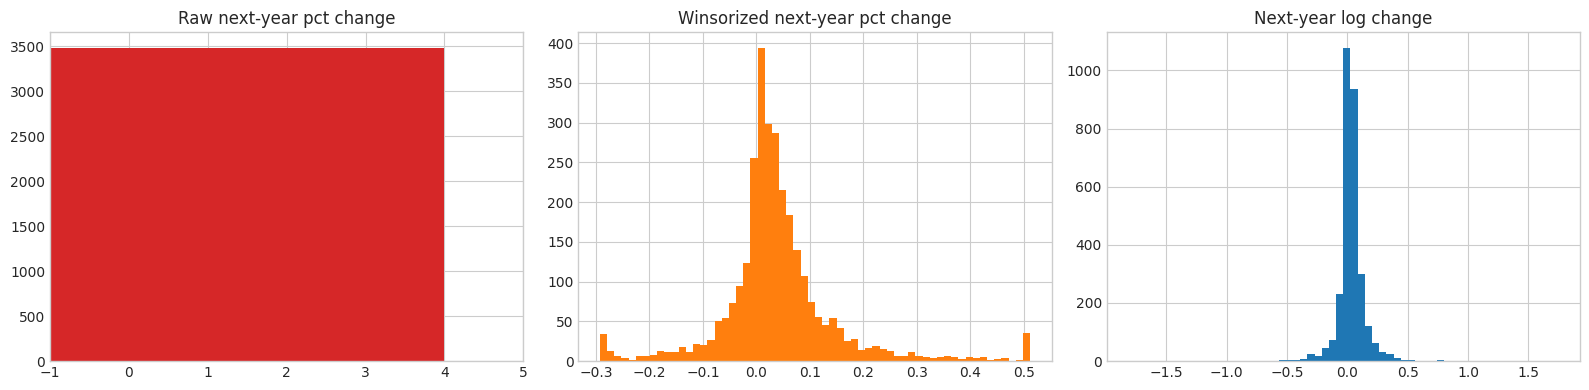

In [5]:
fao_target = (
    fao.loc[(fao["Item"] == TARGET_ITEM) & (fao["Element"] == TARGET_ELEMENT)]
    .copy()
    .rename(columns={"Area": "country", "Year": "year", "Value": "target_value"})
)
fao_target = fao_target[["country", "country_key", "year", "target_value"]]
fao_target = fao_target.sort_values(["country", "year"]).reset_index(drop=True)
fao_target["series_id"] = fao_target["country"]

fao_target["next_year_target"] = fao_target.groupby("series_id")["target_value"].shift(-1)
fao_target["target_lag_1"] = fao_target.groupby("series_id")["target_value"].shift(1)
fao_target["target_lag_2"] = fao_target.groupby("series_id")["target_value"].shift(2)
fao_target["target_pct_change"] = fao_target.groupby("series_id")["target_value"].pct_change()
fao_target["next_year_pct_change_raw"] = fao_target.groupby("series_id")["target_pct_change"].shift(-1)

fao_target["target_log_value"] = np.log1p(fao_target["target_value"])
fao_target["target_log_lag_1"] = fao_target.groupby("series_id")["target_log_value"].shift(1)
fao_target["target_log_lag_2"] = fao_target.groupby("series_id")["target_log_value"].shift(2)
fao_target["target_log_change"] = fao_target.groupby("series_id")["target_log_value"].diff()
fao_target["next_year_log_change"] = fao_target.groupby("series_id")["target_log_change"].shift(-1)

fao_target["small_production_flag"] = (
    (fao_target["target_value"] < MIN_PRODUCTION_TONS)
    | (fao_target["next_year_target"] < MIN_PRODUCTION_TONS)
)

merged = fao_target.merge(outbreak_year, on=["country_key", "year"], how="left")
for feature in OUTBREAK_FEATURE_COLUMNS:
    merged[feature] = merged[feature].fillna(0)
    merged[f"{feature}_lag_1"] = merged.groupby("series_id")[feature].shift(1)
    merged[f"{feature}_lag_2"] = merged.groupby("series_id")[feature].shift(2)

base_modeling_table = merged.dropna(
    subset=["next_year_log_change", "target_lag_1", "target_log_lag_1"]
).copy()

filtered_modeling_table = base_modeling_table.loc[~base_modeling_table["small_production_flag"]].copy()
excluded_rows = base_modeling_table.loc[base_modeling_table["small_production_flag"]].copy()

train_mask = filtered_modeling_table["year"] < TEST_START_YEAR
train_low, train_high = filtered_modeling_table.loc[train_mask, "next_year_pct_change_raw"].quantile([0.01, 0.99])
filtered_modeling_table["next_year_pct_change_winsor"] = filtered_modeling_table["next_year_pct_change_raw"].clip(train_low, train_high)
base_modeling_table["next_year_pct_change_winsor"] = base_modeling_table["next_year_pct_change_raw"].clip(train_low, train_high)

target_summary = pd.DataFrame(
    [
        {
            "target_version": "raw_next_year_pct_change",
            "count": base_modeling_table["next_year_pct_change_raw"].notna().sum(),
            "mean": base_modeling_table["next_year_pct_change_raw"].mean(),
            "std": base_modeling_table["next_year_pct_change_raw"].std(),
            "p01": base_modeling_table["next_year_pct_change_raw"].quantile(0.01),
            "median": base_modeling_table["next_year_pct_change_raw"].median(),
            "p99": base_modeling_table["next_year_pct_change_raw"].quantile(0.99),
            "max": base_modeling_table["next_year_pct_change_raw"].max(),
        },
        {
            "target_version": "winsorized_next_year_pct_change",
            "count": filtered_modeling_table["next_year_pct_change_winsor"].notna().sum(),
            "mean": filtered_modeling_table["next_year_pct_change_winsor"].mean(),
            "std": filtered_modeling_table["next_year_pct_change_winsor"].std(),
            "p01": filtered_modeling_table["next_year_pct_change_winsor"].quantile(0.01),
            "median": filtered_modeling_table["next_year_pct_change_winsor"].median(),
            "p99": filtered_modeling_table["next_year_pct_change_winsor"].quantile(0.99),
            "max": filtered_modeling_table["next_year_pct_change_winsor"].max(),
        },
        {
            "target_version": "next_year_log_change",
            "count": filtered_modeling_table["next_year_log_change"].notna().sum(),
            "mean": filtered_modeling_table["next_year_log_change"].mean(),
            "std": filtered_modeling_table["next_year_log_change"].std(),
            "p01": filtered_modeling_table["next_year_log_change"].quantile(0.01),
            "median": filtered_modeling_table["next_year_log_change"].median(),
            "p99": filtered_modeling_table["next_year_log_change"].quantile(0.99),
            "max": filtered_modeling_table["next_year_log_change"].max(),
        },
    ]
)

sample_summary = pd.DataFrame(
    {
        "metric": [
            "Base modeling rows",
            "Filtered modeling rows",
            "Excluded rows due to small production",
            "Excluded countries",
            "Small-production threshold (tons)",
        ],
        "value": [
            len(base_modeling_table),
            len(filtered_modeling_table),
            len(excluded_rows),
            excluded_rows["country"].nunique(),
            MIN_PRODUCTION_TONS,
        ],
    }
)

excluded_examples = (
    excluded_rows[
        [
            "country",
            "year",
            "target_value",
            "next_year_target",
            "next_year_pct_change_raw",
        ]
    ]
    .assign(abs_next_year_pct_change=lambda df: df["next_year_pct_change_raw"].abs())
    .sort_values("abs_next_year_pct_change", ascending=False)
)

display(sample_summary)
display_section("Target stability comparison", target_summary, rows=10)
display_section("Largest excluded percentage spikes", excluded_examples, rows=15)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(base_modeling_table["next_year_pct_change_raw"].replace([np.inf, -np.inf], np.nan).dropna(), bins=60, color="tab:red")
axes[0].set_title("Raw next-year pct change")
axes[0].set_xlim(-1, 5)

axes[1].hist(filtered_modeling_table["next_year_pct_change_winsor"].dropna(), bins=60, color="tab:orange")
axes[1].set_title("Winsorized next-year pct change")

axes[2].hist(filtered_modeling_table["next_year_log_change"].dropna(), bins=60, color="tab:blue")
axes[2].set_title("Next-year log change")

plt.tight_layout()
plt.show()

## 6. Merge, Lag Checks, and Pre-Model EDA

After target stabilization and filtering, we inspect the filtered modeling table and simple lag relationships before training.

#### Filtered modeling table head

,country,year,target_value,next_year_target,next_year_log_change,outbreak_count,hxnx_subtype_count,severity_index
1,Afghanistan,2006,24400.00,17600.00,-0.326668,13.0,1.0,13.0
2,Afghanistan,2007,17600.00,20800.00,0.167045,9.0,1.0,9.0
3,Afghanistan,2008,20800.00,20000.00,-0.039219,0.0,0.0,0.0
4,Afghanistan,2009,20000.00,28000.00,0.336458,0.0,0.0,0.0
5,Afghanistan,2010,28000.00,25600.00,-0.089609,0.0,0.0,0.0
6,Afghanistan,2011,25600.00,24800.00,-0.031747,0.0,0.0,0.0
7,Afghanistan,2012,24800.00,26400.00,0.062518,0.0,0.0,0.0
8,Afghanistan,2013,26400.00,24809.32,-0.062142,0.0,0.0,0.0
9,Afghanistan,2014,24809.32,24558.74,-0.010151,0.0,0.0,0.0
10,Afghanistan,2015,24558.74,24297.68,-0.010686,0.0,0.0,0.0


#### Lag checks against the stable target

,feature,observations,correlation_with_next_year_log_change,abs_correlation
0,hxnx_subtype_count,3009,-0.005369,0.005369
1,positive_lab_count,3009,-0.004016,0.004016
2,species_diversity,3009,-0.003966,0.003966
3,severity_index,3009,-0.000923,0.000923
4,outbreak_count,3009,-0.000917,0.000917
5,location_spread,3009,-0.000912,0.000912


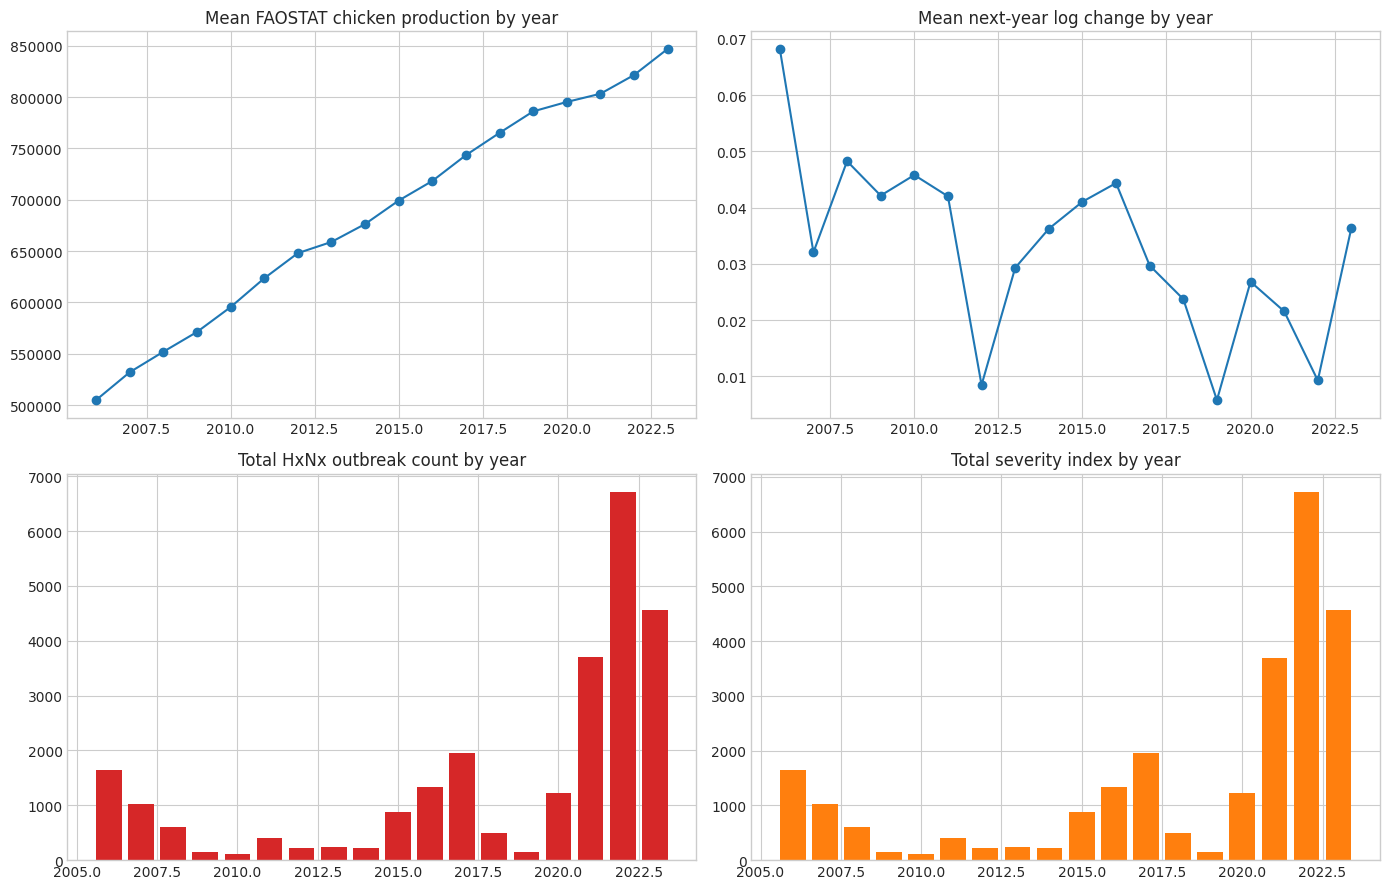

In [6]:
lag_corr_rows = []
for feature in OUTBREAK_FEATURE_COLUMNS:
    pair = filtered_modeling_table[[feature, "next_year_log_change"]].dropna()
    lag_corr_rows.append(
        {
            "feature": feature,
            "observations": len(pair),
            "correlation_with_next_year_log_change": pair[feature].corr(pair["next_year_log_change"]) if len(pair) > 1 else np.nan,
        }
    )
lag_corr_df = (
    pd.DataFrame(lag_corr_rows)
    .assign(abs_correlation=lambda df: df["correlation_with_next_year_log_change"].abs())
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

display_section(
    "Filtered modeling table head",
    filtered_modeling_table[
        [
            "country",
            "year",
            "target_value",
            "next_year_target",
            "next_year_log_change",
            "outbreak_count",
            "hxnx_subtype_count",
            "severity_index",
        ]
    ],
    rows=15,
)
display_section("Lag checks against the stable target", lag_corr_df, rows=10)

year_summary = (
    filtered_modeling_table.groupby("year", as_index=False)
    .agg(
        mean_target_value=("target_value", "mean"),
        mean_next_year_log_change=("next_year_log_change", "mean"),
        total_outbreak_count=("outbreak_count", "sum"),
        total_severity_index=("severity_index", "sum"),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(year_summary["year"], year_summary["mean_target_value"], marker="o")
axes[0, 0].set_title("Mean FAOSTAT chicken production by year")

axes[0, 1].plot(year_summary["year"], year_summary["mean_next_year_log_change"], marker="o", color="tab:blue")
axes[0, 1].set_title("Mean next-year log change by year")

axes[1, 0].bar(year_summary["year"], year_summary["total_outbreak_count"], color="tab:red")
axes[1, 0].set_title("Total HxNx outbreak count by year")

axes[1, 1].bar(year_summary["year"], year_summary["total_severity_index"], color="tab:orange")
axes[1, 1].set_title("Total severity index by year")

plt.tight_layout()
plt.show()

## 7. Explicit Ablation: With Outbreaks vs Without Outbreaks

This is the key comparison the earlier notebook was missing.

We fit the same models on the same filtered sample using:

- **autoregressive only:** target-history features only
- **with outbreaks:** target-history features plus outbreak features and outbreak lags

The primary target here is **next-year log change**.

,model,feature_set,r2,mae,rmse,directional_accuracy
0,ridge,autoregressive_only,-0.001832,0.073765,0.144145,0.694976
1,ridge,with_outbreaks,-0.008505,0.074749,0.144625,0.694976
2,naive_train_mean,baseline,-0.015316,0.073476,0.145112,0.696172
3,naive_zero_change,baseline,-0.019181,0.073223,0.145388,0.007177
4,xgboost,autoregressive_only,-0.054541,0.074145,0.147889,0.692584
5,xgboost,with_outbreaks,-0.058837,0.074117,0.148190,0.694976
6,naive_last_log_change,baseline,-1.441751,0.104394,0.225037,0.608852


#### Ablation focus: with vs without outbreaks

,model,feature_set,r2,mae,rmse,directional_accuracy,model_plus_features
0,ridge,autoregressive_only,-0.001832,0.073765,0.144145,0.694976,ridge | autoregressive_only
1,ridge,with_outbreaks,-0.008505,0.074749,0.144625,0.694976,ridge | with_outbreaks
4,xgboost,autoregressive_only,-0.054541,0.074145,0.147889,0.692584,xgboost | autoregressive_only
5,xgboost,with_outbreaks,-0.058837,0.074117,0.148190,0.694976,xgboost | with_outbreaks


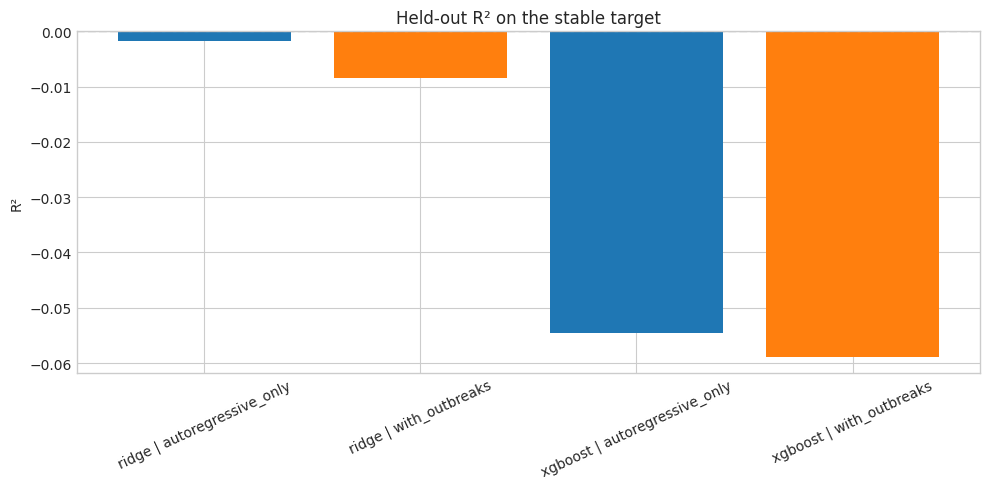

In [7]:
autoregressive_features = [
    "target_log_value",
    "target_log_lag_1",
    "target_log_lag_2",
    "target_log_change",
]

outbreak_augmented_features = autoregressive_features + [
    "outbreak_count",
    "hxnx_subtype_count",
    "positive_lab_count",
    "species_diversity",
    "location_spread",
    "severity_index",
    "outbreak_count_lag_1",
    "outbreak_count_lag_2",
    "positive_lab_count_lag_1",
    "positive_lab_count_lag_2",
    "severity_index_lag_1",
    "severity_index_lag_2",
]

train_df = filtered_modeling_table.loc[filtered_modeling_table["year"] < TEST_START_YEAR].copy()
test_df = filtered_modeling_table.loc[filtered_modeling_table["year"] >= TEST_START_YEAR].copy()

y_train = train_df["next_year_log_change"]
y_test = test_df["next_year_log_change"]

results_rows = []

baseline_predictions = {
    "naive_last_log_change": test_df["target_log_change"].fillna(0).to_numpy(),
    "naive_zero_change": np.zeros(len(test_df)),
    "naive_train_mean": np.repeat(y_train.mean(), len(test_df)),
}

for model_name, pred in baseline_predictions.items():
    results_rows.append(
        {
            "model": model_name,
            "feature_set": "baseline",
            "r2": r2_score(y_test, pred),
            "mae": mean_absolute_error(y_test, pred),
            "rmse": root_mean_squared_error(y_test, pred),
            "directional_accuracy": directional_accuracy(y_test, pred),
        }
    )

for feature_set_name, feature_cols in [
    ("autoregressive_only", autoregressive_features),
    ("with_outbreaks", outbreak_augmented_features),
]:
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]

    ridge = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ]
    )
    ridge.fit(X_train, y_train)
    ridge_pred = ridge.predict(X_test)
    results_rows.append(
        {
            "model": "ridge",
            "feature_set": feature_set_name,
            "r2": r2_score(y_test, ridge_pred),
            "mae": mean_absolute_error(y_test, ridge_pred),
            "rmse": root_mean_squared_error(y_test, ridge_pred),
            "directional_accuracy": directional_accuracy(y_test, ridge_pred),
        }
    )

    xgboost_model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
            (
                "model",
                XGBRegressor(
                    n_estimators=120,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    objective="reg:squarederror",
                    tree_method="hist",
                    device="cpu",
                    n_jobs=4,
                    random_state=42,
                ),
            ),
        ]
    )
    xgboost_model.fit(X_train, y_train)
    xgb_pred = xgboost_model.predict(X_test)
    results_rows.append(
        {
            "model": "xgboost",
            "feature_set": feature_set_name,
            "r2": r2_score(y_test, xgb_pred),
            "mae": mean_absolute_error(y_test, xgb_pred),
            "rmse": root_mean_squared_error(y_test, xgb_pred),
            "directional_accuracy": directional_accuracy(y_test, xgb_pred),
        }
    )

comparison_df = pd.DataFrame(results_rows).sort_values(["r2", "rmse"], ascending=[False, True]).reset_index(drop=True)
display(comparison_df)

ablation_view = comparison_df.loc[comparison_df["feature_set"] != "baseline"].copy()
ablation_view["model_plus_features"] = ablation_view["model"] + " | " + ablation_view["feature_set"]
display_section("Ablation focus: with vs without outbreaks", ablation_view, rows=10)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = ablation_view.copy()
ax.bar(plot_df["model_plus_features"], plot_df["r2"], color=["tab:blue", "tab:orange", "tab:blue", "tab:orange"])
ax.axhline(0, color="black", linestyle="--")
ax.set_title("Held-out R² on the stable target")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 8. Updated Findings

The original notebook ended with a broad positive-sounding takeaway. This revision replaces that with a more direct read of what the stabilized target and ablation actually say.

In [8]:
best_row = comparison_df.iloc[0]
ridge_ablation = comparison_df.loc[comparison_df["model"] == "ridge"].sort_values("feature_set").reset_index(drop=True)
xgb_ablation = comparison_df.loc[comparison_df["model"] == "xgboost"].sort_values("feature_set").reset_index(drop=True)

ridge_delta_r2 = (
    ridge_ablation.loc[ridge_ablation["feature_set"] == "with_outbreaks", "r2"].iloc[0]
    - ridge_ablation.loc[ridge_ablation["feature_set"] == "autoregressive_only", "r2"].iloc[0]
)
xgb_delta_r2 = (
    xgb_ablation.loc[xgb_ablation["feature_set"] == "with_outbreaks", "r2"].iloc[0]
    - xgb_ablation.loc[xgb_ablation["feature_set"] == "autoregressive_only", "r2"].iloc[0]
)

strongest_corr = lag_corr_df.iloc[0]

display(
    Markdown(
        f"""
### Updated notebook readout

- **Primary target now:** next-year log difference, with very small-production rows excluded below **{MIN_PRODUCTION_TONS:,} tons**.
- **Rows removed for stability:** **{len(excluded_rows):,}** of **{len(base_modeling_table):,}** candidate modeling rows.
- **Raw target problem:** raw next-year percent change still reaches **{base_modeling_table['next_year_pct_change_raw'].max():.3f}**, confirming the original instability.
- **Stable target spread:** filtered next-year log change has mean **{filtered_modeling_table['next_year_log_change'].mean():.4f}** and std **{filtered_modeling_table['next_year_log_change'].std():.4f}**.
- **Best held-out row:** **{best_row["model"]} / {best_row["feature_set"]}** with R² **{best_row["r2"]:.4f}**, MAE **{best_row["mae"]:.4f}**, RMSE **{best_row["rmse"]:.4f}**, and directional accuracy **{best_row["directional_accuracy"]:.3f}**.
- **Outbreak ablation for Ridge:** adding outbreaks changes R² by **{ridge_delta_r2:.4f}**.
- **Outbreak ablation for XGBoost:** adding outbreaks changes R² by **{xgb_delta_r2:.4f}**.
- **Strongest simple outbreak relationship:** `{strongest_corr["feature"]}` with correlation **{strongest_corr["correlation_with_next_year_log_change"]:.4f}**.

### Interpretation

- The target is now much better behaved than the original raw percent-change target.
- The notebook now makes the outbreak contribution explicit instead of implying it.
- If the outbreak-augmented models do not beat the autoregressive-only versions, then the current outbreak features are not adding useful predictive information on this proxy target.
- That is a valid outcome, and it is more trustworthy than a headline metric built on unstable percentage spikes.
        """
    )
)


### Updated notebook readout

- **Primary target now:** next-year log difference, with very small-production rows excluded below **1,000 tons**.
- **Rows removed for stability:** **480** of **3,489** candidate modeling rows.
- **Raw target problem:** raw next-year percent change still reaches **299.000**, confirming the original instability.
- **Stable target spread:** filtered next-year log change has mean **0.0328** and std **0.1432**.
- **Best held-out row:** **ridge / autoregressive_only** with R² **-0.0018**, MAE **0.0738**, RMSE **0.1441**, and directional accuracy **0.695**.
- **Outbreak ablation for Ridge:** adding outbreaks changes R² by **-0.0067**.
- **Outbreak ablation for XGBoost:** adding outbreaks changes R² by **-0.0043**.
- **Strongest simple outbreak relationship:** `hxnx_subtype_count` with correlation **-0.0054**.

### Interpretation

- The target is now much better behaved than the original raw percent-change target.
- The notebook now makes the outbreak contribution explicit instead of implying it.
- If the outbreak-augmented models do not beat the autoregressive-only versions, then the current outbreak features are not adding useful predictive information on this proxy target.
- That is a valid outcome, and it is more trustworthy than a headline metric built on unstable percentage spikes.
        